In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # 使用GPU 0

import torch
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM, GenerationConfig
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = '/data2/models/OneKE/ZJUNLP/OneKE'

print(f"使用设备: {device}")
print("加载模型（不使用量化，直接bfloat16）...")

config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    config=config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)
model.eval()
print("✅ 模型加载完成！")

使用设备: cuda
加载模型（不使用量化，直接bfloat16）...


KeyboardInterrupt: 

: 

In [ ]:
def extract(instruction, schema, text):
    system = '<<SYS>>\nYou are a helpful assistant. 你是一个乐于助人的助手。\n<</SYS>>\n\n'
    prompt = '[INST] ' + system + json.dumps({"instruction": instruction, "schema": schema, "input": text}, ensure_ascii=False) + '[/INST]'
    
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    output = model.generate(
        input_ids=input_ids, 
        generation_config=GenerationConfig(max_length=1024, max_new_tokens=512, return_dict_in_generate=True), 
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(output.sequences[0][input_ids.size(1):], skip_special_tokens=True)

print("✅ 推理函数已定义")

✅ 推理函数已定义


In [ ]:
# 测试1: 实体抽取 (NER)
text1 = "2024年，马云在杭州参加了阿里巴巴集团的年度会议。"
result1 = extract(
    "你是实体识别专家。从输入中抽取符合schema的实体，不存在返回空列表。用JSON格式回答。",
    ["人物", "组织机构", "地理位置"],
    text1
)
print(f"【NER - 实体抽取】\n文本: {text1}\n结果: {result1}\n{'-'*60}\n")

# 测试2: 关系抽取 (RE)
text2 = "阿里巴巴集团由马云于1999年在杭州创立。"
result2 = extract(
    "你是关系抽取专家。从输入中抽取符合schema的关系三元组，不存在返回空列表。用JSON格式回答。",
    ["创始人", "总部地点", "成立时间"],
    text2
)
print(f"【RE - 关系抽取】\n文本: {text2}\n结果: {result2}\n{'-'*60}\n")

# 测试3: 事件抽取 (EE)
text3 = "11月25日，华为在深圳总部举行新品发布会，正式发布了Mate 60系列手机。"
result3 = extract(
    "你是事件抽取专家。从输入中抽取符合schema的事件，不存在返回空列表。用JSON格式回答。",
    ["会议召开", "产品发布"],
    text3
)
print(f"【EE - 事件抽取】\n文本: {text3}\n结果: {result3}")

【NER - 实体抽取】
文本: 2024年，马云在杭州参加了阿里巴巴集团的年度会议。
结果: {"人物": ["马云"], "组织机构": ["阿里巴巴集团"], "地理位置": ["杭州"]}
------------------------------------------------------------

【RE - 关系抽取】
文本: 阿里巴巴集团由马云于1999年在杭州创立。
结果: {"创始人": [{"subject": "阿里巴巴集团", "object": "马云"}], "总部地点": [{"subject": "阿里巴巴集团", "object": "杭州"}], "成立时间": [{"subject": "阿里巴巴集团", "object": "1999年"}]}
------------------------------------------------------------

【EE - 事件抽取】
文本: 11月25日，华为在深圳总部举行新品发布会，正式发布了Mate 60系列手机。
结果: {"会议召开": [], "产品发布": [{"时间": "11月25日", "发布产品": "Mate 60系列手机"}]}


In [ ]:
data_path = '/root/projects/cwy/DeepKE/example/llm/InstructKGC/data/NER/sample.json'

with open(data_path, 'r', encoding='utf-8') as f:
    samples = [json.loads(line) for line in f]

print(f"加载了 {len(samples)} 条测试数据，测试前3条:\n")

instruction = "你是实体识别专家。从输入中抽取符合schema的实体，不存在返回空列表。用JSON格式回答。"
schema = ["人物", "组织机构", "地理位置"]

for i, sample in enumerate(samples[:3], 1):
    print(f"\n{'='*60}")
    print(f"测试 {i}: {sample['text']}")
    print(f"真实标注: {sample.get('entity', [])}")
    
    result = extract(instruction, schema, sample['text'])
    print(f"模型预测: {result}")

加载了 6 条测试数据，测试前3条:


测试 1: 在这里恕弟不恭之罪，敢在尊前一诤：前人论书，每曰“字字有来历，笔笔有出处”，细读公字，何尝跳出前人藩篱，自隶变而后，直至明季，兄有何新出？
真实标注: []
模型预测: {"人物": [], "组织机构": [], "地理位置": []}

测试 2: 相比之下，青岛海牛队和广州松日队的雨中之战虽然也是0∶0，但乏善可陈。
真实标注: [{'entity': '广州松日队', 'entity_type': '组织机构'}, {'entity': '青岛海牛队', 'entity_type': '组织机构'}]
模型预测: {"人物": [], "组织机构": ["青岛海牛队", "广州松日队"], "地理位置": []}

测试 3: 理由多多，最无奈的却是：5月恰逢双重考试，她攻读的博士学位论文要通考；她任教的两所学校，也要在这段时日大考。
真实标注: []
模型预测: {"人物": [], "组织机构": [], "地理位置": []}


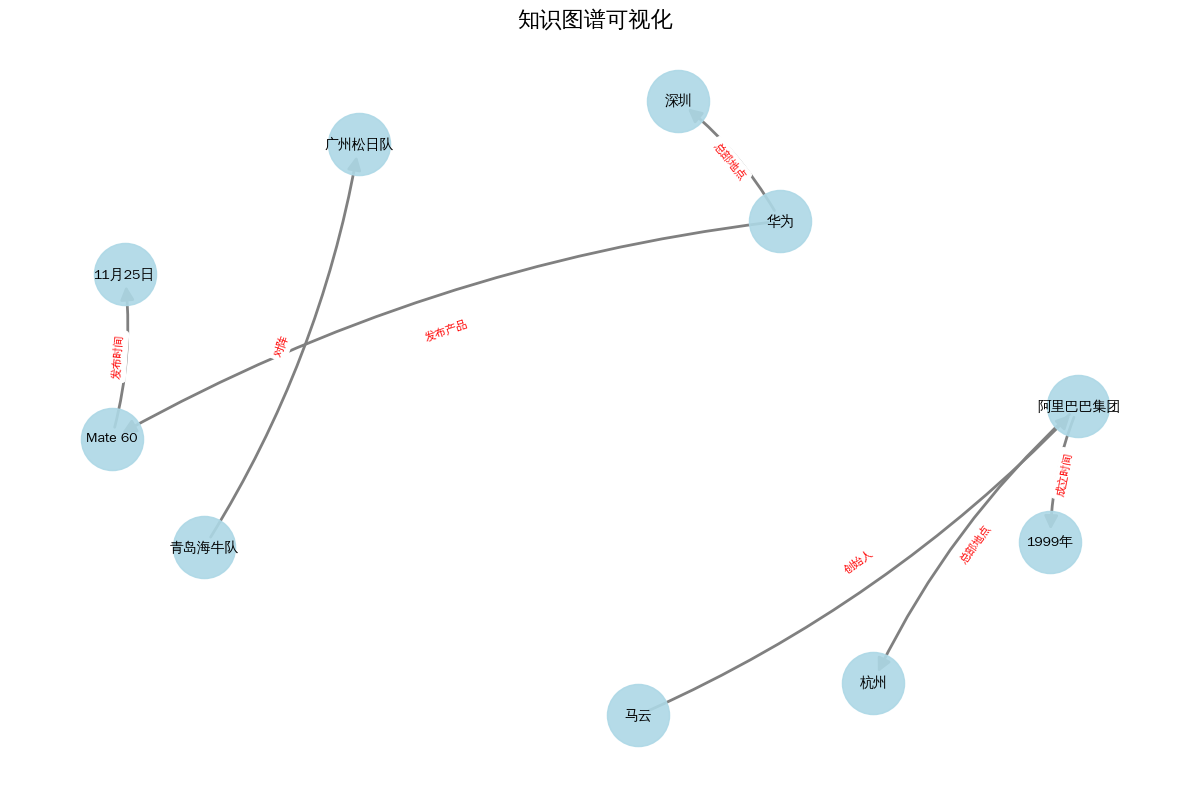

✅ 知识图谱构建完成！
节点数: 10
边数: 7

所有三元组:
  (马云, 创始人, 阿里巴巴集团)
  (阿里巴巴集团, 总部地点, 杭州)
  (阿里巴巴集团, 成立时间, 1999年)
  (华为, 发布产品, Mate 60)
  (华为, 总部地点, 深圳)
  (Mate 60, 发布时间, 11月25日)
  (青岛海牛队, 对阵, 广州松日队)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
# plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
# plt.rcParams['axes.unicode_minus'] = False



# 使用 WenQuanYi 字体（刚安装的）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# 创建有向图
G = nx.DiGraph()

# 从前面的抽取结果构建三元组
# NER + RE 的结果
triples = [
    ("马云", "创始人", "阿里巴巴集团"),
    ("阿里巴巴集团", "总部地点", "杭州"),
    ("阿里巴巴集团", "成立时间", "1999年"),
    ("华为", "发布产品", "Mate 60"),
    ("Mate 60", "发布时间", "11月25日"),
    ("华为", "总部地点", "深圳"),
    ("青岛海牛队", "对阵", "广州松日队"),
]

# 添加边（自动创建节点）
for head, relation, tail in triples:
    G.add_edge(head, tail, relation=relation)

# 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=2, iterations=50)  # 布局

# 画节点
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, alpha=0.9)

# 画边
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                       arrowsize=20, width=2, connectionstyle='arc3,rad=0.1')

# 画标签
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# 画边的标签（关系）
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, font_color='red')

plt.title("知识图谱可视化", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✅ 知识图谱构建完成！")
print(f"节点数: {G.number_of_nodes()}")
print(f"边数: {G.number_of_edges()}")
print(f"\n所有三元组:")
for head, tail, data in G.edges(data=True):
    print(f"  ({head}, {data['relation']}, {tail})")

/tmp/ipykernel_2902080/870939728.py:104: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/data2/hjq/env/deepke-llm/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


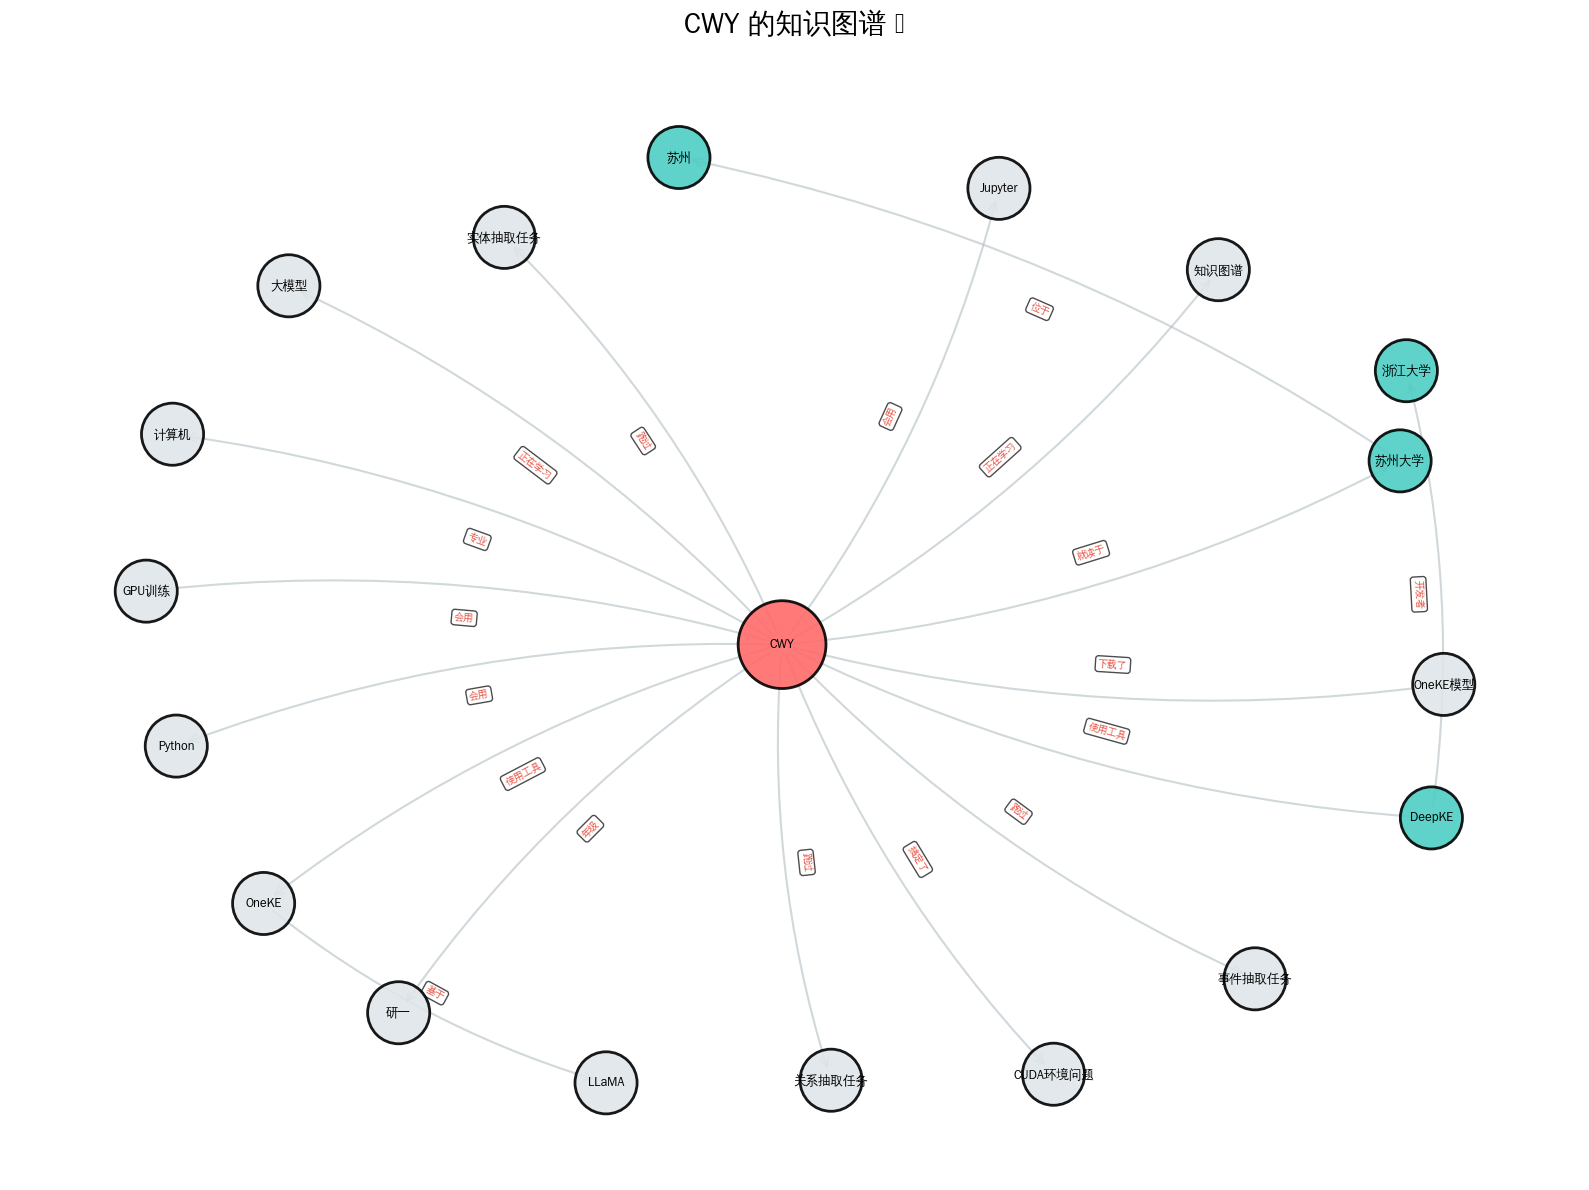

✅ CWY 的知识图谱构建完成！

📊 图谱统计:
  节点数: 19
  关系数: 18

🎯 关于 CWY 的所有知识:
  • 就读于: 苏州大学
  • 年级: 研一
  • 专业: 计算机
  • 正在学习: 知识图谱
  • 正在学习: 大模型
  • 使用工具: DeepKE
  • 使用工具: OneKE
  • 跑过: 实体抽取任务
  • 跑过: 关系抽取任务
  • 跑过: 事件抽取任务
  • 会用: Python
  • 会用: Jupyter
  • 会用: GPU训练
  • 搞定了: CUDA环境问题
  • 下载了: OneKE模型

📚 所有三元组:
  (CWY, 就读于, 苏州大学)
  (CWY, 年级, 研一)
  (CWY, 专业, 计算机)
  (CWY, 正在学习, 知识图谱)
  (CWY, 正在学习, 大模型)
  (CWY, 使用工具, DeepKE)
  (CWY, 使用工具, OneKE)
  (CWY, 跑过, 实体抽取任务)
  (CWY, 跑过, 关系抽取任务)
  (CWY, 跑过, 事件抽取任务)
  (CWY, 会用, Python)
  (CWY, 会用, Jupyter)
  (CWY, 会用, GPU训练)
  (CWY, 搞定了, CUDA环境问题)
  (CWY, 下载了, OneKE模型)
  (苏州大学, 位于, 苏州)
  (DeepKE, 开发者, 浙江大学)
  (OneKE, 基于, LLaMA)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建有向图
G = nx.DiGraph()

# 构建三元组 - 关于 CWY 的知识
triples = [
    # 基本信息
    ("CWY", "就读于", "苏州大学"),
    ("CWY", "年级", "研一"),
    ("CWY", "专业", "计算机"),
    
    # 学习相关
    ("CWY", "正在学习", "知识图谱"),
    ("CWY", "正在学习", "大模型"),
    ("CWY", "使用工具", "DeepKE"),
    ("CWY", "使用工具", "OneKE"),
    
    # 项目经验
    ("CWY", "跑过", "实体抽取任务"),
    ("CWY", "跑过", "关系抽取任务"),
    ("CWY", "跑过", "事件抽取任务"),
    
    # 技能
    ("CWY", "会用", "Python"),
    ("CWY", "会用", "Jupyter"),
    ("CWY", "会用", "GPU训练"),
    
    # 成就（可以自己加）
    ("CWY", "搞定了", "CUDA环境问题"),
    ("CWY", "下载了", "OneKE模型"),
    
    # 关联
    ("苏州大学", "位于", "苏州"),
    ("DeepKE", "开发者", "浙江大学"),
    ("OneKE", "基于", "LLaMA"),
]

# 定义节点类型和颜色
node_colors = {}
for head, relation, tail in triples:
    # 中心节点
    if head == "CWY":
        node_colors[head] = '#FF6B6B'  # 红色 - 主角
    # 学校相关
    elif head in ["苏州大学", "浙江大学"] or tail in ["苏州大学", "浙江大学"]:
        node_colors[head] = '#4ECDC4'  # 青色
        node_colors[tail] = '#4ECDC4'
    # 技能/工具
    elif relation in ["会用", "使用工具"]:
        node_colors[tail] = '#95E1D3'  # 浅绿
    # 学习内容
    elif relation == "正在学习":
        node_colors[tail] = '#F9CA24'  # 黄色
    # 任务
    elif relation == "跑过":
        node_colors[tail] = '#A29BFE'  # 紫色
    # 成就
    elif relation in ["搞定了", "下载了"]:
        node_colors[tail] = '#FD79A8'  # 粉色
    # 其他
    else:
        if head not in node_colors:
            node_colors[head] = '#DFE6E9'
        if tail not in node_colors:
            node_colors[tail] = '#DFE6E9'

# 添加边
for head, relation, tail in triples:
    G.add_edge(head, tail, relation=relation)

# 准备节点颜色列表（按节点顺序）
colors = [node_colors.get(node, '#DFE6E9') for node in G.nodes()]

# 计算节点大小（中心节点大一点）
sizes = [4000 if node == "CWY" else 2000 for node in G.nodes()]

# 绘图
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)  # 固定随机种子，布局更稳定

# 画节点
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9, edgecolors='black', linewidths=2)

# 画边
nx.draw_networkx_edges(G, pos, edge_color='#B2BEC3', arrows=True, 
                       arrowsize=15, width=1.5, connectionstyle='arc3,rad=0.1', 
                       alpha=0.6, arrowstyle='->')

# 画节点标签
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# 画边的标签（关系）
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, font_color='#E74C3C', 
                             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title("CWY 的知识图谱 🎓", fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# 打印统计信息
print(f"✅ {list(G.nodes())[0]} 的知识图谱构建完成！")
print(f"\n📊 图谱统计:")
print(f"  节点数: {G.number_of_nodes()}")
print(f"  关系数: {G.number_of_edges()}")

print(f"\n🎯 关于 CWY 的所有知识:")
for head, tail, data in G.edges(data=True):
    if head == "CWY":
        print(f"  • {data['relation']}: {tail}")

print(f"\n📚 所有三元组:")
for head, tail, data in G.edges(data=True):
    print(f"  ({head}, {data['relation']}, {tail})")

In [1]:
# 安装依赖（如果没装）
# !pip install pdfplumber networkx matplotlib -q

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM
import json
import pdfplumber
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

# 配置中文字体
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载 OneKE 模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = '/data2/models/OneKE/ZJUNLP/OneKE'

print(f"使用设备: {device}")
print("加载 OneKE 模型...")

config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    config=config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)
model.eval()
print("✅ 模型加载完成！")

使用设备: cuda
加载 OneKE 模型...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

✅ 模型加载完成！


In [7]:
# 1. OneKE 抽取函数
def extract_knowledge(instruction, schema, text):
    """使用 OneKE 抽取知识"""
    system = '<<SYS>>\nYou are a helpful assistant. 你是一个乐于助人的助手。\n<</SYS>>\n\n'
    prompt = '[INST] ' + system + json.dumps({
        "instruction": instruction, 
        "schema": schema, 
        "input": text
    }, ensure_ascii=False) + '[/INST]'
    
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            input_ids=input_ids, 
            max_new_tokens=512,
            pad_token_id=tokenizer.eos_token_id
        )
    # 修复：直接使用 output[0]，不用 .sequences
    result = tokenizer.decode(output[0][input_ids.size(1):], skip_special_tokens=True)
    return result

# 2. PDF 提取函数
def extract_text_from_pdf(pdf_path, max_pages=10):
    """从 PDF 提取文本（默认前10页）"""
    print(f"正在读取 PDF: {pdf_path}")
    paragraphs = []
    
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = min(len(pdf.pages), max_pages)
        print(f"将处理前 {total_pages} 页...")
        
        for i, page in enumerate(pdf.pages[:total_pages]):
            text = page.extract_text()
            if text:
                # 按换行符分段，过滤短段落
                segments = [s.strip() for s in text.split('\n') if len(s.strip()) > 20]
                paragraphs.extend(segments)
                
        print(f"✅ 提取完成！共 {len(paragraphs)} 个段落")
    return paragraphs

# 3. 批量抽取函数
def batch_extract(paragraphs, schema_config, max_chunks=20):
    """批量抽取知识（默认处理前20个段落）"""
    results = {
        "entities": defaultdict(list),
        "relations": []
    }
    
    # NER Schema
    ner_instruction = "你是命名实体识别专家。请从input中抽取出符合schema定义的实体，不存在的实体类型返回空列表。请按照JSON字符串的格式回答。"
    ner_schema = schema_config["entities"]
    
    # RE Schema
    re_instruction = "你是关系抽取专家。请从input中抽取出符合schema定义的关系三元组，不存在的关系类型返回空列表。请按照JSON字符串的格式回答。"
    re_schema = schema_config["relations"]
    
    print(f"\n开始批量抽取（共 {min(len(paragraphs), max_chunks)} 个段落）...")
    
    for idx, para in enumerate(paragraphs[:max_chunks]):
        print(f"\n{'='*80}")
        print(f"处理第 {idx+1}/{min(len(paragraphs), max_chunks)} 段")
        print(f"{'='*80}")
        print(f"📄 完整文本:\n{para}\n")
        print(f"{'-'*80}")
        
        # 抽取实体
        try:
            ner_result = extract_knowledge(ner_instruction, ner_schema, para)
            ner_data = json.loads(ner_result)
            for entity_type, entities in ner_data.items():
                results["entities"][entity_type].extend(entities)
            print(f"✅ 实体抽取结果:\n{ner_result}\n")
        except Exception as e:
            print(f"⚠️ NER 失败: {e}\n")
        
        # 抽取关系
        try:
            re_result = extract_knowledge(re_instruction, re_schema, para)
            re_data = json.loads(re_result)
            for rel_type, triples in re_data.items():
                if isinstance(triples, list):
                    for triple in triples:
                        if isinstance(triple, dict) and 'subject' in triple and 'object' in triple:
                            results["relations"].append((triple['subject'], rel_type, triple['object']))
            print(f"✅ 关系抽取结果:\n{re_result}\n")
        except Exception as e:
            print(f"⚠️ RE 失败: {e}\n")
    
    # 去重
    for entity_type in results["entities"]:
        results["entities"][entity_type] = list(set(results["entities"][entity_type]))
    results["relations"] = list(set(results["relations"]))
    
    print(f"\n✅ 批量抽取完成！")
    print(f"   实体总数: {sum(len(v) for v in results['entities'].values())}")
    print(f"   关系总数: {len(results['relations'])}")
    
    return results

print("✅ 函数定义完成！")

✅ 函数定义完成！


In [10]:
# 定义书籍通用 Schema
book_schema = {
    "entities": ["人物", "概念", "方法", "理论", "组织", "书籍"],
    "relations": ["提出", "包含", "应用", "来源", "解释", "相关"]
}

# PDF 路径
pdf_path = "/root/projects/cwy/DeepKE/cwy/data/家庭教育-亲子关系-链接力-核心能力《非暴力.pdf"

# # 提取文本（前5页测试）
# paragraphs = extract_text_from_pdf(pdf_path, max_pages=5)

# # 批量抽取（前10段测试）
# knowledge_graph = batch_extract(paragraphs, book_schema, max_chunks=10)

# 提取文本（前100页）
paragraphs = extract_text_from_pdf(pdf_path, max_pages=100)

# 批量抽取（所有段落，最多500段）
knowledge_graph = batch_extract(paragraphs, book_schema, max_chunks=500)

# 打印统计
print("\n" + "="*60)
print("📊 抽取结果统计:")
print("="*60)
for entity_type, entities in knowledge_graph["entities"].items():
    print(f"{entity_type}: {len(entities)} 个")
    if entities:
        print(f"  示例: {entities[:3]}")
print(f"\n关系三元组: {len(knowledge_graph['relations'])} 个")
if knowledge_graph['relations']:
    print("  示例:")
    for rel in knowledge_graph['relations'][:5]:
        print(f"    {rel}")

正在读取 PDF: /root/projects/cwy/DeepKE/cwy/data/家庭教育-亲子关系-链接力-核心能力《非暴力.pdf
将处理前 100 页...
✅ 提取完成！共 1399 个段落

开始批量抽取（共 500 个段落）...

处理第 1/500 段
📄 完整文本:
马歇尔·卢森堡博士发现了一种沟通方式，依照它来谈话和聆听，

--------------------------------------------------------------------------------
✅ 实体抽取结果:
{"人物": ["马歇尔·卢森堡"], "概念": [], "方法": [], "理论": ["沟通方式"], "组织": [], "书籍": []}

✅ 关系抽取结果:
{"提出": [{"subject": "沟通方式", "object": "马歇尔·卢森堡"}], "包含": [], "应用": [], "来源": [], "解释": [], "相关": []}


处理第 2/500 段
📄 完整文本:
能使人们情意相通，和谐相处，这就是“非暴力沟通”。

--------------------------------------------------------------------------------
✅ 实体抽取结果:
{"人物": [], "概念": [], "方法": ["非暴力沟通"], "理论": [], "组织": [], "书籍": []}

✅ 关系抽取结果:
{"提出": [], "包含": [], "应用": [], "来源": [], "解释": [{"subject": "非暴力沟通", "object": "使人们情意相通，和谐相处"}], "相关": []}


处理第 3/500 段
📄 完整文本:
做为一个遵纪守法的好人，也许我们从来没有把谈话和“暴力”扯上

--------------------------------------------------------------------------------
✅ 实体抽取结果:
{"人物": [], "概念": [], "方法": [], "理论": [], "组织": [], "书籍": []}

✅ 关系抽取结果:


知识图谱统计:
  节点数: 5
  边数: 2


/tmp/ipykernel_2352888/3949239011.py:51: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()


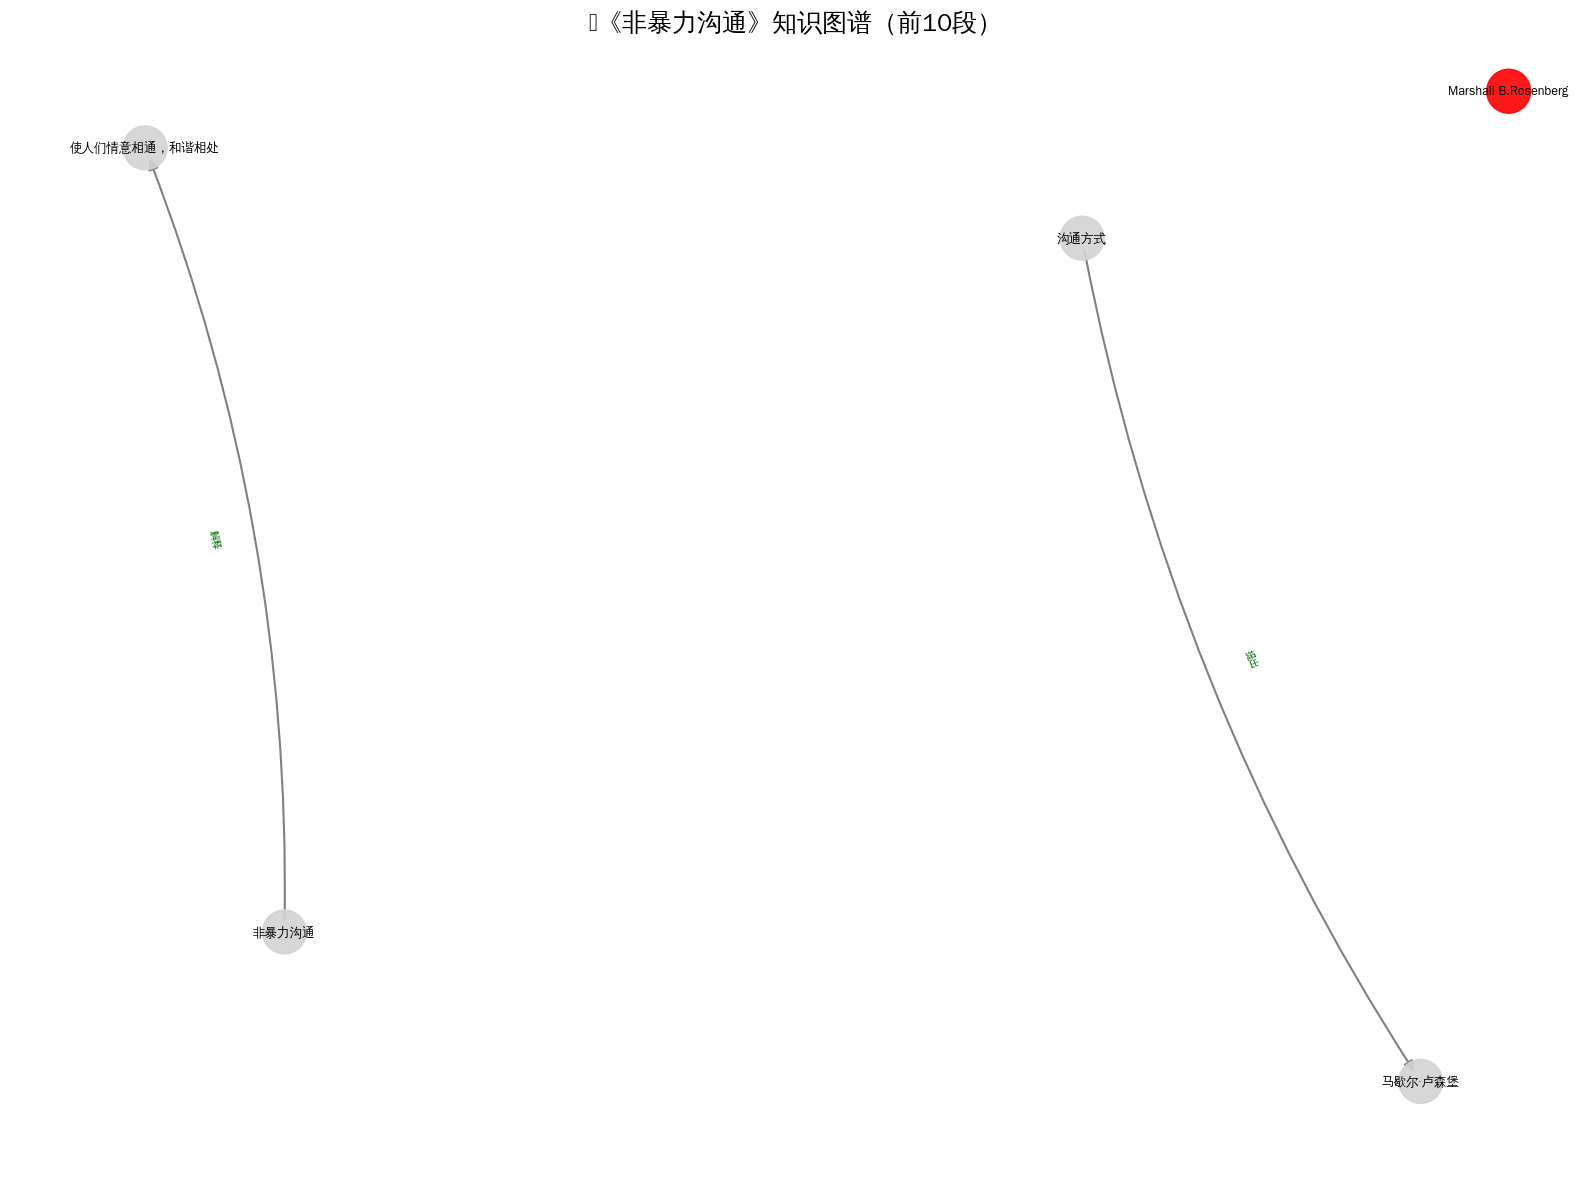


✅ 结果已保存到: /root/projects/cwy/DeepKE/cwy/src/kg_result.json


In [9]:
# 构建知识图谱
G = nx.DiGraph()

# 添加关系边
for head, relation, tail in knowledge_graph["relations"]:
    G.add_edge(head, tail, relation=relation)

# 添加孤立实体节点
for entity_type, entities in knowledge_graph["entities"].items():
    for entity in entities:
        if entity not in G.nodes():
            G.add_node(entity, type=entity_type)

print(f"知识图谱统计:")
print(f"  节点数: {G.number_of_nodes()}")
print(f"  边数: {G.number_of_edges()}")

# 可视化
if G.number_of_nodes() > 0:
    plt.figure(figsize=(16, 12))
    
    # 布局
    pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
    
    # 节点颜色（按类型）
    node_colors = []
    color_map = {
        "人物": "red", "概念": "blue", "方法": "green",
        "理论": "orange", "组织": "purple", "书籍": "cyan"
    }
    for node in G.nodes():
        node_type = G.nodes[node].get('type', 'default')
        node_colors.append(color_map.get(node_type, 'lightgray'))
    
    # 画节点
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, alpha=0.9)
    
    # 画边
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, 
                          arrowsize=15, width=1.5, connectionstyle='arc3,rad=0.1')
    
    # 画标签
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    # 画边标签
    edge_labels = nx.get_edge_attributes(G, 'relation')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, font_color='darkgreen')
    
    plt.title(f"📚《非暴力沟通》知识图谱（前{len(paragraphs[:10])}段）", fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 保存结果
    output_path = "/root/projects/cwy/DeepKE/cwy/src/kg_result.json"
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump({
            "entities": dict(knowledge_graph["entities"]),
            "relations": knowledge_graph["relations"]
        }, f, ensure_ascii=False, indent=2)
    print(f"\n✅ 结果已保存到: {output_path}")
else:
    print("⚠️ 未抽取到足够的知识，请检查 PDF 内容或增加处理页数")